In [ ]:
import pandas as pd
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784", as_frame=False)

In [ ]:
X, y = mnist.data, mnist.target

# split data
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [ ]:
import matplotlib.pyplot as plt


def plot_digit(image_data):
    # takes in one instance of image data and displays it
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

In [ ]:
y_train_5 = y_train == "5"
y_test_5 = y_test == "5"

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

In [ ]:
from sklearn.model_selection import cross_val_score

# cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

In [ ]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)

In [ ]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")

In [ ]:
# custom cross-validation

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone


def custom_cross_val(given_n_splits, classfier):

    skfolds = StratifiedKFold(n_splits=given_n_splits)

    for train_index, test_index in skfolds.split(X_train, y_train_5):
        clone_clf = clone(classfier)
        X_train_folds = X_train[train_index]
        y_train_folds = y_train_5[train_index]
        X_test_folds = X_train[test_index]
        y_test_folds = y_train_5[test_index]

        clone_clf.fit(X_train_folds, y_train_folds)
        y_pred = clone_clf.predict(X_test_folds)
        n_correct = sum(y_pred == y_test_folds)
        print(n_correct / len(y_test_folds))


# custom_cross_val(given_n_splits=3, classfier=sgd_clf)

In [ ]:
from sklearn.model_selection import cross_val_predict

# y_train_pred = cross_val_predict(sgd_clf, X_train, y_train, cv=3)

In [ ]:
y_train_pred5 = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_5, y_train_pred5)
cm_dataframe = pd.DataFrame(cm)
cm_dataframe

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("5-classifier: ")
print(precision_score(y_train_5, y_train_pred5))
print(recall_score(y_train_5, y_train_pred5))
print(f1_score(y_train_5, y_train_pred5))

In [ ]:
y_scores = cross_val_predict(
    sgd_clf, X_train, y_train_5, cv=3, method="decision_function"
)
y_scores

In [ ]:
from sklearn.metrics import precision_recall_curve

threshold = 3000

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")

idx = (thresholds >= threshold).argmax()
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")

plt.show()

In [ ]:
# plotting precision vs recall
plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")

plt.axis([0, 1, 0, 1])
plt.plot([recalls[idx]], [precisions[idx]], "ko", label="Point at threshold 3,000")
plt.vlines(recalls[idx], 0, 1.0, "k", "dotted")
plt.hlines(precisions[idx], 0, 1.0, "k", "dotted")
plt.grid()
plt.ylabel("Precision")

plt.xlabel("Recall")
plt.legend(loc="lower left")

In [ ]:
idx_for_90p = (precisions >= 0.90).argmax()
threshold_for_90p = thresholds[idx_for_90p]
threshold_for_90p

In [ ]:
y_train_pred5_90 = y_scores >= threshold_for_90p

precision_score(y_train_5, y_train_pred5_90)
recall_score(y_train_5, y_train_pred5_90)

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, threshold = roc_curve(y_train_5, y_scores)

idx_for_threshold_at_90 = (thresholds <= threshold_for_90p).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.plot(fpr, tpr, linewidth=2, label="ROC Curve")
plt.plot([0, 1], [0, 1], "k:", label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")

plt.axis([0, 1, 0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid()
plt.legend(loc="lower right")
plt.show()

In [ ]:
roc_auc_score(y_train_5, y_scores)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(
    forest_clf, X_train, y_train_5, cv=3, method="predict_proba"
)

In [ ]:
y_scores_forest = y_probas_forest[:, 1]
precisions_f, recalls_f, thresholds_f = precision_recall_curve(
    y_train_5, y_scores_forest
)


def plot_PRC(precisions, recalls):
    plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")
    plt.axis([0, 1, 0, 1])
    plt.ylabel("Precision")
    plt.xlabel("Recall")
    plt.legend(loc="lower left")


def plot_ROC(fpr, tpr):

    plt.plot(fpr, tpr, linewidth=2, label="ROC Curve")
    plt.plot([0, 1], [0, 1], "k:", label="Random classifier's ROC curve")

    plt.axis([0, 1, 0, 1])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid()
    plt.legend(loc="lower right")

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_PRC(precisions, recalls, thresholds)
plot_PRC(precisions_f, recalls_f, thresholds_f)
plt.grid()

fpr_f, tpr_f, threshold = roc_curve(y_train_5, y_scores_forest)

plt.subplot(1, 2, 2)
plot_ROC(fpr, tpr)
plot_ROC(fpr_f, tpr_f)
plt.grid()

<h1>Multi-Class Classification</h1>


In [ ]:
from sklearn.svm import SVC

svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype("float64"))

In [ ]:
cross_val_score(
    svm_clf, X_train_scaled[:2000], y_train[:2000], cv=3, scoring="accuracy"
)

In [ ]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)
#takes around 1.5mins

In [ ]:
import os
import joblib

to_load = 'y_train_pred_scaled.pkl'

# if (os.path.exists(filename)):
#     y_train_pred = joblib.load(filename)
#     print("Loaded sgd predictions from memory")
# else:
#     print("Computing sgd preditictions ~17min")
#     y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
#     joblib.dump(y_train_pred, filename)

def get_predictions(filename, classifier, X_train, y_train, cv):
    if (os.path.exists(filename)):
        print("Loaded predictions from memory")
        return joblib.load(filename)
    else:
        print("Computing sgd preditictions ~17min")
        predictions = cross_val_predict(classifier, X_train, y_train, cv=cv)
        joblib.dump(predictions, filename)
        return predictions

y_train_pred = get_predictions(to_load, sgd_clf,X_train_scaled, y_train, 3)

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_train, y_train_pred, normalize="true", values_format=".0%"
)
plt.show()

In [ ]:
sample_weight = (y_train_pred != y_train)
ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_train_pred,
    sample_weight=sample_weight,
    normalize="true",
    values_format=".0%",
)
plt.show()

In [ ]:
cl_a, cl_b = '3', '5'
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

#copy from collab
size = 5
pad = 0.2
plt.figure(figsize=(size, size))
for images, (label_col, label_row) in [(X_ba, (0, 0)), (X_bb, (1, 0)),
                                       (X_aa, (0, 1)), (X_ab, (1, 1))]:
    for idx, image_data in enumerate(images[:size*size]):
        x = idx % size + label_col * (size + pad)
        y = idx // size + label_row * (size + pad)
        plt.imshow(image_data.reshape(28, 28), cmap="binary",
                   extent=(x, x + 1, y, y + 1))
        
plt.xticks([size / 2, size + pad + size / 2], [str(cl_a), str(cl_b)])
plt.yticks([size / 2, size + pad + size / 2], [str(cl_b), str(cl_a)])
plt.plot([size + pad / 2, size + pad / 2], [0, 2 * size + pad], "k:")
plt.plot([0, 2 * size + pad], [size + pad / 2, size + pad / 2], "k:")
plt.axis([0, 2 * size + pad, 0, 2 * size + pad])
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.show()

In [ ]:
#multilabel classification

import numpy as np
from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= '7')
y_train_odd = (y_train.astype('int8') % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

In [ ]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train[:20000], y_multilabel[:20000], cv=3)

In [ ]:
f1_score(y_multilabel[:20000], y_train_knn_pred, average="macro")

In [ ]:
#making noisy MNIST training set
rng = np.random.default_rng(seed=42)
noise_train = rng.integers(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise_train
noise_test = rng.integers(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise_test

y_train_mod = X_train
y_test_mod = X_test

In [ ]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_mod, y_train_mod)

ValueError: cannot reshape array of size 1 into shape (28,28)

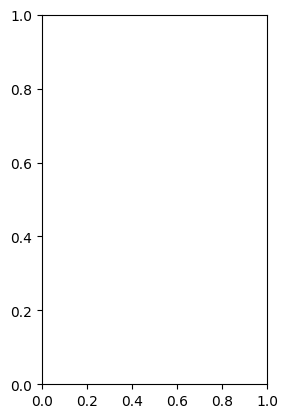

In [97]:
to_predict = X_test_mod[0]

clean_digit = knn_clf.predict([to_predict])
plt.subplot(1,2,1)
plot_digit(clean_digit)
plt.subplot(1,2,2)
plot_digit(to_predict)

In [63]:
from sklearn.model_selection import GridSearchCV

param_grid = [{'weights': ["uniform", "distance"], 'n_neighbors': [3, 4, 5, 6]}]

knn_clf = KNeighborsClassifier()
grid_search = GridSearchCV(knn_clf, param_grid, cv=5)
grid_search.fit(X_train[:10_000], y_train[:10_000])

,estimator,KNeighborsClassifier()
,param_grid,"[{'n_neighbors': [3, 4, ...], 'weights': ['uniform', 'distance']}]"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,4


In [66]:
grid_search.best_score_

np.float64(0.9441999999999998)

In [67]:
# grid_search.best_estimator_.fit(X_train, y_train)
# tuned_accuracy = grid_search.score(X_test, y_test)
# tuned_accuracy

0.9714

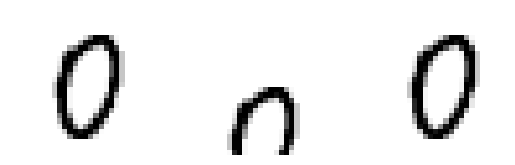

In [74]:
from scipy.ndimage import shift
    
def shift_image(image, dx,dy):
    reshaped=image.reshape(28,28)
    shifted = shift(reshaped, [dy,dx], cval=0)
    return shifted.reshape([-1])

image = X_train[1000]
plt.subplot(1,3,1)
plot_digit(shift_image(image, 0, 0))
plt.subplot(1,3,2)
plot_digit(shift_image(image, 0, 1))
plt.subplot(1,3,3)
plot_digit(shift_image(image, 1, 0))


In [ ]:
X_train_augmented = [image for image in X_train]
y_train_augmented = [label for label in y_train]

for dx,dy in ((0,-1), (0,1), (1,0), (-1,0)):
    for image, label in zip(X_train, y_train):
        X_train_augmented.append(shift_image(image, dx,dy))
        y_train_augmented.append(label)

In [86]:
X_train_augmented = np.array(X_train_augmented)
y_train_augmented = np.array(y_train_augmented)

In [88]:
shuffle_idx = rng.permutation(len(X_train_augmented))
X_train_augmented = X_train_augmented[shuffle_idx]
y_train_augmented = y_train_augmented[shuffle_idx]

In [93]:
knn_clf = KNeighborsClassifier(**grid_search.best_params_)
knn_clf.fit(X_train_augmented, y_train_augmented)


,n_neighbors,4
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [94]:
augmented_accuracy = knn_clf.score(X_test, y_test)
augmented_accuracy

0.0993